Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('R:/PROJECTS/User Journey Funnel Analysis/user_journey_funnel_analysis/retail_user_behavior_100k/retail_user_behavior_100k.csv')

In [4]:
df.head(10)

,session_id,user_id,timestamp_utc,event_index,user_action,product_id,category,brand,price,channel,device_type,region,traffic_source,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
0,S0000001,U000372,2026-01-08T02:34:40Z,1,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,25,4,1,0,0
1,S0000001,U000372,2026-01-08T02:35:20Z,2,wishlist,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,28,4,2,0,0
2,S0000001,U000372,2026-01-08T02:35:43Z,3,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,5,4,3,0,0
3,S0000001,U000372,2026-01-08T02:36:13Z,4,drop,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,16,4,4,0,1
4,S0000002,U004812,2026-01-29T11:07:27Z,1,view,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,15,4,1,0,0
5,S0000002,U004812,2026-01-29T11:07:40Z,2,add_to_cart,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,6,4,2,0,0
6,S0000002,U004812,2026-01-29T11:08:00Z,3,view,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,5,4,3,0,0
7,S0000002,U004812,2026-01-29T11:08:49Z,4,drop,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,34,4,4,0,1
8,S0000003,U001935,2026-03-08T08:35:30Z,1,view,P1816,Groceries,FreshFarm,261.82,web,android,AU,organic,27,6,1,0,0
9,S0000003,U001935,2026-03-08T08:35:51Z,2,click,P1816,Groceries,FreshFarm,261.82,web,android,AU,organic,14,6,2,0,0


In [31]:
df.shape #Checking the dimesion of the dataset

(108584, 18)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108584 entries, 0 to 108583
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   session_id         108584 non-null  str    
 1   user_id            108584 non-null  str    
 2   timestamp_utc      108584 non-null  str    
 3   event_index        108584 non-null  int64  
 4   user_action        108584 non-null  str    
 5   product_id         108584 non-null  str    
 6   category           108584 non-null  str    
 7   brand              108584 non-null  str    
 8   price              108584 non-null  float64
 9   channel            108584 non-null  str    
 10  device_type        108584 non-null  str    
 11  region             108584 non-null  str    
 12  traffic_source     108584 non-null  str    
 13  time_spent_sec     108584 non-null  int64  
 14  session_length     108584 non-null  int64  
 15  interaction_count  108584 non-null  int64  
 16  is_conversion

In [10]:
df.isna().sum() #Cheking the Null values

session_id           0
user_id              0
timestamp_utc        0
event_index          0
user_action          0
product_id           0
category             0
brand                0
price                0
channel              0
device_type          0
region               0
traffic_source       0
time_spent_sec       0
session_length       0
interaction_count    0
is_conversion        0
drop_off_flag        0
dtype: int64

In [34]:
df.duplicated().sum() #Checking the duplicates

np.int64(0)

In [30]:
df.describe()

,event_index,price,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
count,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000
mean,3.834626,249.497547,17.828317,6.669251,3.834626,0.038707,0.127063
std,2.238094,145.627749,9.356853,2.038962,2.238094,0.192897,0.333045
min,1.000000,7.290000,3.000000,3.000000,1.000000,0.000000,0.000000
25%,2.000000,119.950000,11.000000,5.000000,2.000000,0.000000,0.000000
50%,4.000000,253.850000,18.000000,7.000000,4.000000,0.000000,0.000000
75%,5.000000,376.080000,24.000000,8.000000,5.000000,0.000000,0.000000
max,13.000000,499.860000,64.000000,13.000000,13.000000,1.000000,1.000000


Exploratory Data Analysis

In [48]:
print(f'Number of Unique session is : {df['session_id'].nunique()}') #Number of unique sessions

Number of Unique session is : 18000


In [47]:
print(f'Number of Unique user is : {df['user_id'].nunique()}') #Number of unique users

Number of Unique user is : 6806


In [42]:
df['timestamp_utc'].dtype

<StringDtype(na_value=nan)>

In [46]:
#Changing timestamp_utc to date type

df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
print(f'Data type of timestamp_utc column is : {df['timestamp_utc'].dtype}')

Data type of timestamp_utc column is : datetime64[us, UTC]


In [56]:
df[['event_index','user_action']].head(10)

,event_index,user_action
0,1,view
1,2,wishlist
2,3,view
3,4,drop
4,1,view
5,2,add_to_cart
6,3,view
7,4,drop
8,1,view
9,2,click


In [57]:
df['user_action'].value_counts()

user_action
view           44245
click          27735
drop           13797
add_to_cart    11642
wishlist        6962
purchase        4203
Name: count, dtype: int64

Text(0, 0.5, 'Values')

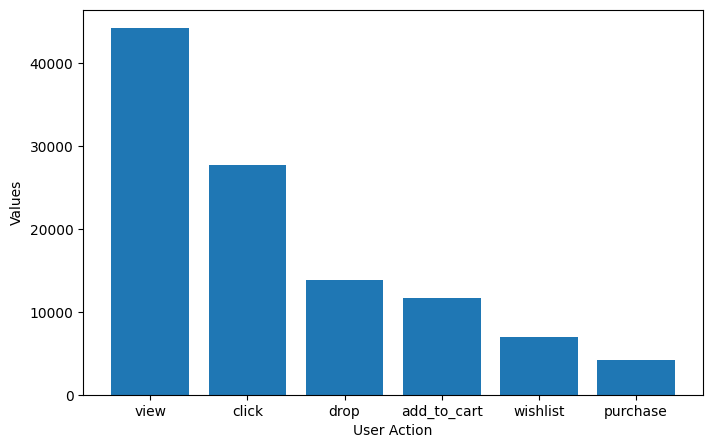

In [ ]:
plt.figure(figsize=(8,5))
x = df['user_action'].value_counts().index
y = df['user_action'].value_counts().values

plt.bar(x,y,)
plt.xlabel('User Action')
plt.ylabel('Values')

In [73]:
funnel = df.groupby('user_action')['user_id'].nunique().sort_values(ascending=False)
funnel

user_action
view           6806
click          6353
drop           6278
add_to_cart    5187
wishlist       4014
purchase       3238
Name: user_id, dtype: int64

In [ ]:
#Dividing the entire series by the value of the first step (view)
overall_conversion = (funnel / funnel.iloc[0]) * 100

print(overall_conversion.round(2))

user_action
view           100.00
click           93.34
drop            92.24
add_to_cart     76.21
wishlist        58.98
purchase        47.58
Name: user_id, dtype: float64


In [93]:
#Shifting the series by 1 to align each step with its previous step
step_conversion = (funnel / funnel.shift(1)) * 100

#Fill the first step with 100% since it has no prior step
step_conversion = step_conversion.fillna(100)

print(step_conversion.round(2))

user_action
view           100.00
click           93.34
drop            98.82
add_to_cart     82.62
wishlist        77.39
purchase        80.67
Name: user_id, dtype: float64


In [94]:
#Drop-off Analysis
drop_off = (funnel.shift(1)-funnel) 

#Fill the first step with 0 since as no one has drop-off
drop_off = drop_off.fillna(0)

print(drop_off.astype('int64'))

user_action
view              0
click           453
drop             75
add_to_cart    1091
wishlist       1173
purchase        776
Name: user_id, dtype: int64


In [95]:
#Subtract each stage count from the very first stage (view)
cumulative_dropoff = funnel.iloc[0] - funnel

print(cumulative_dropoff)

user_action
view              0
click           453
drop            528
add_to_cart    1619
wishlist       2792
purchase       3568
Name: user_id, dtype: int64


In [102]:
#Drop-off rates
drop_off_rates = ((funnel.shift(1) - funnel) / funnel.shift(1)) * 100
drop_off_rates = drop_off_rates.fillna(100)
drop_off_rates

user_action
view           100.000000
click            6.655892
drop             1.180545
add_to_cart     17.378146
wishlist        22.614228
purchase        19.332337
Name: user_id, dtype: float64